In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Lab 10 Exercise 2 - K-Means Image Compression (396x396x3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image
import requests
from io import BytesIO

In [ ]:
from skimage import data as skdata
img_array = skdata.coffee()
img_array = np.array(Image.fromarray(img_array).resize((396, 396)))
print("Image shape:", img_array.shape)

Image shape: (396, 396, 3)


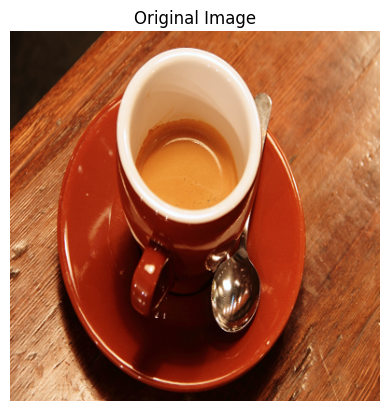

In [ ]:
plt.imshow(img_array)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [ ]:
pixels = img_array.reshape(-1, 3)
print("Pixels shape:", pixels.shape)
print("Total pixels:", pixels.shape[0])

Pixels shape: (156816, 3)
Total pixels: 156816


In [ ]:
k = 16
model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
model.fit(pixels)
print("Cluster centers shape:", model.cluster_centers_.shape)

Cluster centers shape: (16, 3)


In [ ]:
compressed_pixels = model.cluster_centers_[model.labels_]
compressed_img = compressed_pixels.reshape(396, 396, 3).astype(np.uint8)
print("Compressed image shape:", compressed_img.shape)

Compressed image shape: (396, 396, 3)


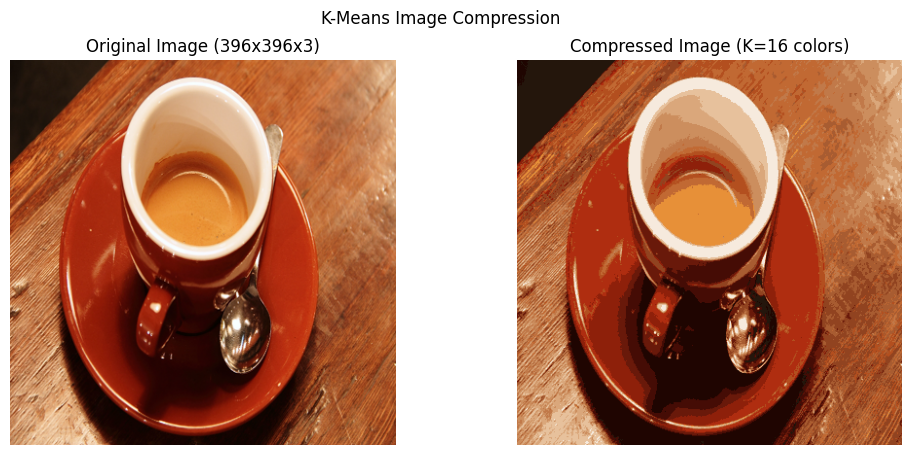

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_array)
axes[0].set_title('Original Image (396x396x3)')
axes[0].axis('off')
axes[1].imshow(compressed_img)
axes[1].set_title(f'Compressed Image (K={k} colors)')
axes[1].axis('off')
plt.suptitle('K-Means Image Compression')
plt.show()

In [ ]:
original_size = img_array.nbytes
compressed_size = k * 3 + len(model.labels_)
print(f"Original size: {original_size} bytes")
print(f"Compressed size (approx): {compressed_size} bytes")
print(f"Colors reduced to: {k} colors from 16 million possible")
print(f"Compression ratio: {original_size/compressed_size:.1f}x")

Original size: 470448 bytes
Compressed size (approx): 156864 bytes
Colors reduced to: 16 colors from 16 million possible
Compression ratio: 3.0x


In [ ]:
print("Observation:")
print(f"Original image uses up to 16 million colors (256^3)")
print(f"K-Means reduced it to just {k} representative colors")
print("Each pixel is replaced by its nearest cluster center color")
print("Image quality is reduced but storage size is significantly smaller")

Observation:
Original image uses up to 16 million colors (256^3)
K-Means reduced it to just 16 representative colors
Each pixel is replaced by its nearest cluster center color
Image quality is reduced but storage size is significantly smaller
